In [2]:
# الخطوة 1: تحميل البيانات من Kaggle
import kagglehub, pandas as pd, os, re, warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("nalgondalokesh/drug-food-interaction-dataset")
df = pd.read_csv(os.path.join(path, "drug_food_interactions.csv"))
print(f"✅ البيانات جاهزة: {df.shape[0]} صف")
print(df.head(3))

100%|██████████| 59.7k/59.7k [00:00<00:00, 21.6MB/s]

Extracting files...
✅ البيانات جاهزة: 2512 صف
          name                                          reference  \
0    Lepirudin  Knox C, Wilson M, Klinger CM, et al. DrugBank ...   
1  Bivalirudin  Knox C, Wilson M, Klinger CM, et al. DrugBank ...   
2  Bivalirudin  Knox C, Wilson M, Klinger CM, et al. DrugBank ...   

                                   food_interactions  
0  Avoid herbs and supplements with anticoagulant...  
1                                   Avoid echinacea.  
2  Avoid herbs and supplements with anticoagulant...  


📊 توزيع الفئات:
label
Avoid                  981
Monitor                715
Take With Food         471
General Interaction    278
Limit                   67
Name: count, dtype: int64


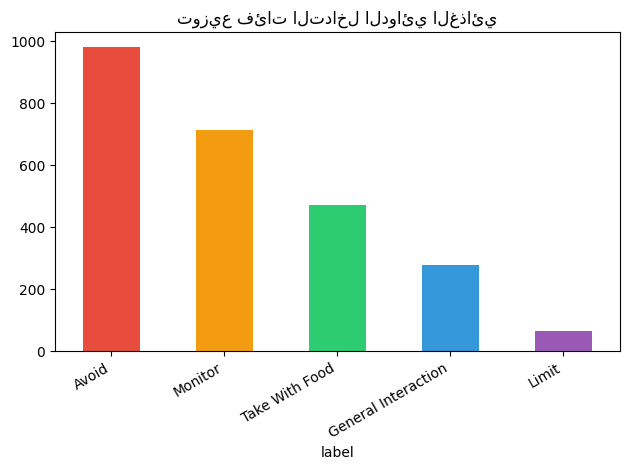

In [3]:
import re
# الخطوة 2: NLP - تصنيف نوع التداخل من النص
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# تنظيف النص
df['clean'] = df['food_interactions'].fillna('').astype(str).str.lower()
df['clean'] = df['clean'].str.replace(r'[^a-z ]+', ' ', regex=True).str.strip()

# تصنيف تلقائي بالكلمات المفتاحية
def label(t):
    t = str(t).lower()
    if not t.strip(): return 'No Interaction'
    if any(w in t for w in ['avoid','do not',"don't",'contraindicated','dangerous','toxic','fatal']): return 'Avoid'
    if any(w in t for w in ['increase','decrease','reduce','absorption','level','affect','alter']): return 'Monitor'
    if any(w in t for w in ['with food','with meal','with milk','with water','take with']): return 'Take With Food'
    if any(w in t for w in ['limit','moderate','caution','grapefruit','caffeine','alcohol']): return 'Limit'
    return 'General Interaction'

df['label'] = df['food_interactions'].apply(label)
print("📊 توزيع الفئات:")
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71','#3498db','#9b59b6'])
plt.title('توزيع فئات التداخل الدوائي الغذائي')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [4]:
import re
# الخطوة 3: تدريب نموذج NLP (TF-IDF + Logistic Regression)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['label'])
X = df['clean']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"🏋️ تدريب: {len(X_train)} | 🧪 اختبار: {len(X_test)}")

# النموذج: TF-IDF + Logistic Regression
model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ دقة النموذج: {acc:.2%}")
print("\n📋 تقرير تفصيلي:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

🏋️ تدريب: 2009 | 🧪 اختبار: 503

✅ دقة النموذج: 96.42%

📋 تقرير تفصيلي:
                     precision    recall  f1-score   support

              Avoid       0.99      0.98      0.99       197
General Interaction       0.89      0.98      0.93        56
              Limit       1.00      0.77      0.87        13
            Monitor       0.94      0.97      0.95       143
     Take With Food       1.00      0.94      0.97        94

           accuracy                           0.96       503
          macro avg       0.96      0.93      0.94       503
       weighted avg       0.97      0.96      0.96       503



In [6]:
import re

# ✅ الخطوة 4: دالة التنبؤ الذكية - تبحث في الداتاسيت أولاً
def predict(drug_name, food_name):
    drug_rows = df[df['name'].str.lower() == drug_name.lower()]
    icons = {'Avoid':'🔴','Monitor':'🟡','Take With Food':'🟢',
             'Limit':'🟠','General Interaction':'🔵','No Interaction':'⚪'}
    print("="*50)
    print(f"💊 الدواء: {drug_name} | 🍽️ الأكل: {food_name}")

    # الدواء مو موجود في الداتاسيت
    if drug_rows.empty:
        print(f"⚪ الدواء غير موجود في الداتاسيت - لا تداخل موثّق")
        print("="*50)
        return 'No Data'

    interaction_text = drug_rows['food_interactions'].fillna('').values[0]

    # مافي تداخل موثّق للدواء
    if not interaction_text.strip():
        print(f"⚪ No Interaction - لا تداخل موثّق لهذا الدواء")
        print("="*50)
        return 'No Interaction'

    # هل الأكل مذكور صراحةً في التحذيرات؟
    food_mentioned = food_name.lower() in interaction_text.lower()

    # تصنيف التداخل العام للدواء بالنموذج
    clean_text = re.sub(r'[^a-z ]+', ' ', interaction_text.lower()).strip()
    pred_enc = model.predict([clean_text])[0]
    pred_label = le.inverse_transform([pred_enc])[0]
    proba = model.predict_proba([clean_text])[0].max()

    if food_mentioned:
        print(f"⚠️  {food_name} مذكور في تحذيرات الدواء!")
        print(f"🔮 {icons.get(pred_label,'❓')} {pred_label} | 📊 الثقة: {proba:.1%}")
        print(f"📋 التحذير: {interaction_text[:120]}...")
    else:
        print(f"✅ {food_name} غير مذكور في تحذيرات الدواء — آمن!")
        print(f"📋 التداخل الموثّق للدواء مع: {interaction_text[:100]}...")
        print(f"ℹ️  التصنيف العام للدواء: {icons.get(pred_label,'❓')} {pred_label}")

    print("="*50)
    return pred_label

# اختبارات
predict("atorvastatin", "orange")
print()
predict("atorvastatin", "grapefruit")
print()
predict("warfarin", "spinach")
print()
predict("amlodipine", "grapefruit")


💊 الدواء: atorvastatin | 🍽️ الأكل: orange
✅ orange غير مذكور في تحذيرات الدواء — آمن!
📋 التداخل الموثّق للدواء مع: Avoid grapefruit products. Grapefruit products may increase the risk for atorvastatin related advers...
ℹ️  التصنيف العام للدواء: 🔴 Avoid

💊 الدواء: atorvastatin | 🍽️ الأكل: grapefruit
⚠️  grapefruit مذكور في تحذيرات الدواء!
🔮 🔴 Avoid | 📊 الثقة: 93.4%
📋 التحذير: Avoid grapefruit products. Grapefruit products may increase the risk for atorvastatin related adverse effects such as my...

💊 الدواء: warfarin | 🍽️ الأكل: spinach
✅ spinach غير مذكور في تحذيرات الدواء — آمن!
📋 التداخل الموثّق للدواء مع: Avoid drastic dietary changes....
ℹ️  التصنيف العام للدواء: 🔴 Avoid

💊 الدواء: amlodipine | 🍽️ الأكل: grapefruit
⚠️  grapefruit مذكور في تحذيرات الدواء!
🔮 🔴 Avoid | 📊 الثقة: 99.2%
📋 التحذير: Avoid grapefruit products....


'Avoid'